# Thesis Notebook 14 — Modality & Interpretability Analysis

**Purpose:** Provide interpretable explanations of which feature/modality groups drive CatBoost's performance,
using both CatBoost built-in feature importance and SHAP values.

**Key thesis claim:** Audio embeddings (PANNs, MERT, VGGish, Mel Stats) provide the most predictive signal for
acoustic targets (Energy, Danceability), while text-based features (MPNet, Text Stats, Sentiment) contribute more
to the emotion-related target (Valence).

**Note:** This notebook loads the saved CatBoost models and the 4,254-feature test arrays. SHAP computation on the
full test set may take several minutes.

In [10]:
import warnings

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

REPO = Path().resolve().parent
FEAT = REPO / 'ml' / 'features'
MODELS_DIR = REPO / 'ml' / 'models' / 'saved' / 'thesis_ml_test'
FIGS = REPO / 'results' / 'figures' / 'thesis'
FIGS.mkdir(parents=True, exist_ok=True)

TARGETS = ['valence', 'energy', 'danceability', 'popularity']
TARGET_LABELS = ['Valence', 'Energy', 'Danceability', 'Popularity']

# Feature block definitions (matching thesis_ml_models.py)
MODALITIES = [
    ('audio',      'Base Audio',  23),
    ('text_stats', 'Text Stats',   5),
    ('sentiment',  'Sentiment',    2),
    ('mpnet',      'MPNet',      768),
    ('vggish',     'VGGish',     128),
    ('mert',       'MERT',       768),
    ('panns',      'PANNs',     2048),
    ('mel_stats',  'Mel Stats',  512),
]
# Build index ranges for each modality
modality_ranges = {}
start = 0
for key, label, dim in MODALITIES:
    modality_ranges[label] = (start, start + dim)
    start += dim
assert start == 4254, f'Expected 4254 features, got {start}'

# Audio-only modality keys (for text column naming)
AUDIO_FEAT_FILE = FEAT / 'audio_feature_names.txt'

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})
print('Setup complete. Modality ranges:')
for label, (s, e) in modality_ranges.items():
    print(f'  {label:<14}: dims {s}:{e} ({e-s} features)')

Setup complete. Modality ranges:
  Base Audio    : dims 0:23 (23 features)
  Text Stats    : dims 23:28 (5 features)
  Sentiment     : dims 28:30 (2 features)
  MPNet         : dims 30:798 (768 features)
  VGGish        : dims 798:926 (128 features)
  MERT          : dims 926:1694 (768 features)
  PANNs         : dims 1694:3742 (2048 features)
  Mel Stats     : dims 3742:4254 (512 features)


## 1. Load Models & Test Data

In [11]:
# Load saved CatBoost_tuned models
models = {}
for tgt in TARGETS:
    path = MODELS_DIR / f'CatBoost_tuned_{tgt}.pkl'
    models[tgt] = joblib.load(path)
    print(f'Loaded CatBoost_tuned for {tgt}: {path.name}')

# Load test feature arrays and concatenate to 4254-feature matrix
print('\nLoading test features...')
arrays = []
for key, label, dim in MODALITIES:
    arr = np.load(FEAT / f'X_test_{key}.npy').astype(np.float32)
    assert arr.shape[1] == dim, f'{label}: expected {dim}, got {arr.shape[1]}'
    arrays.append(arr)
    print(f'  {label:<14}: {arr.shape}')

X_test = np.hstack(arrays).astype(np.float32)
print(f'\nX_test shape: {X_test.shape}')

# Load test targets
y_test = {tgt: np.load(FEAT / f'y_test_{tgt}.npy') for tgt in TARGETS}
print('Targets loaded.')

Loaded CatBoost_tuned for valence: CatBoost_tuned_valence.pkl
Loaded CatBoost_tuned for energy: CatBoost_tuned_energy.pkl
Loaded CatBoost_tuned for danceability: CatBoost_tuned_danceability.pkl
Loaded CatBoost_tuned for popularity: CatBoost_tuned_popularity.pkl

Loading test features...
  Base Audio    : (74573, 23)
  Text Stats    : (74573, 5)
  Sentiment     : (74573, 2)
  MPNet         : (74573, 768)
  VGGish        : (74573, 128)
  MERT          : (74573, 768)
  PANNs         : (74573, 2048)
  Mel Stats     : (74573, 512)

X_test shape: (74573, 4254)
Targets loaded.


## 2. Figure 1 — CatBoost Feature Importance Aggregated by Modality

In [12]:
def get_modality_importance(model, modality_ranges):
    """Aggregate CatBoost feature_importances_ by modality block."""
    fi = model.get_feature_importance()  # shape: (4254,)
    modality_imp = {}
    for label, (s, e) in modality_ranges.items():
        modality_imp[label] = fi[s:e].sum()
    # Normalise to sum to 100
    total = sum(modality_imp.values())
    return {k: v / total * 100 for k, v in modality_imp.items()}

importance_by_target = {tgt: get_modality_importance(models[tgt], modality_ranges) for tgt in TARGETS}
importance_df = pd.DataFrame(importance_by_target).T  # shape: (4 targets, 8 modalities)
importance_df.index = TARGET_LABELS
print('Modality importance (%) per target:')
print(importance_df.round(2).to_string())

Modality importance (%) per target:
              Base Audio  Text Stats  Sentiment  MPNet  VGGish   MERT  PANNs  Mel Stats
Valence             9.59        0.97       0.01   2.10   32.29  17.17  26.17      11.71
Energy             38.40        0.32       0.00   0.48   24.05   6.56  11.93      18.25
Danceability       22.13        1.24       0.01   1.74   43.72   8.62  17.54       5.00
Popularity         46.92        2.60       0.01  11.43   16.29   5.21  11.06       6.48


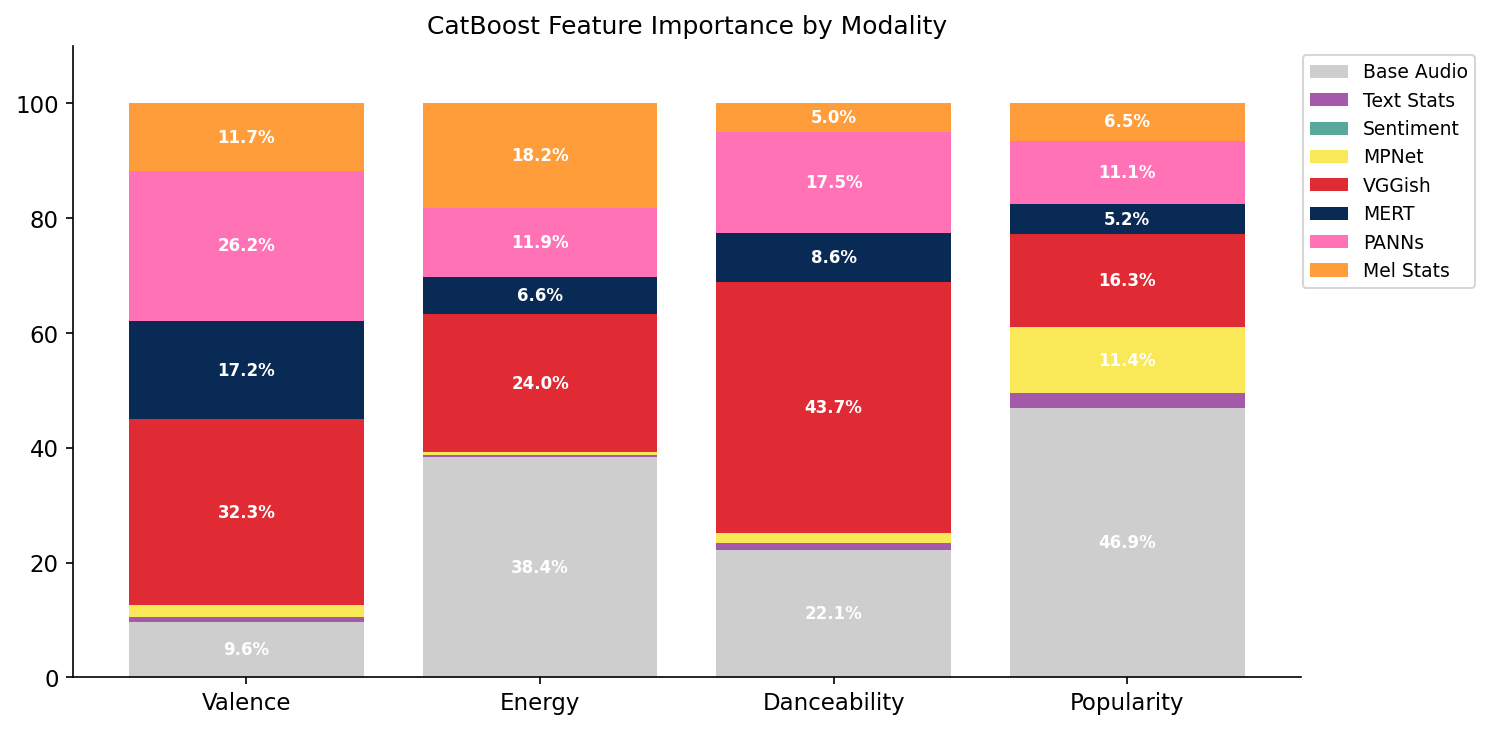

Saved: 14_catboost_modality_importance.png


In [13]:
modality_order = list(modality_ranges.keys())
modality_colors = [
    '#CECECE', '#A559AA', '#59A89C', '#F9E858',
    '#E02B35', '#082A54', '#FF73B6', '#FF9D3A'
]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(TARGETS))
bottom = np.zeros(len(TARGETS))

for mod, col in zip(modality_order, modality_colors):
    vals = importance_df[mod].values
    bars = ax.bar(x, vals, bottom=bottom, label=mod, color=col)
    # Label segments > 5%
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(xi, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(TARGET_LABELS)
# ax.set_ylabel('Feature Importance (%)' )
ax.set_title('CatBoost Feature Importance by Modality')
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=9)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig(FIGS / '14_catboost_modality_importance.png', bbox_inches='tight')
plt.show()
print('Saved: 14_catboost_modality_importance.png')

## 3. Figure 2 — Per-Target Modality Contribution Heatmap

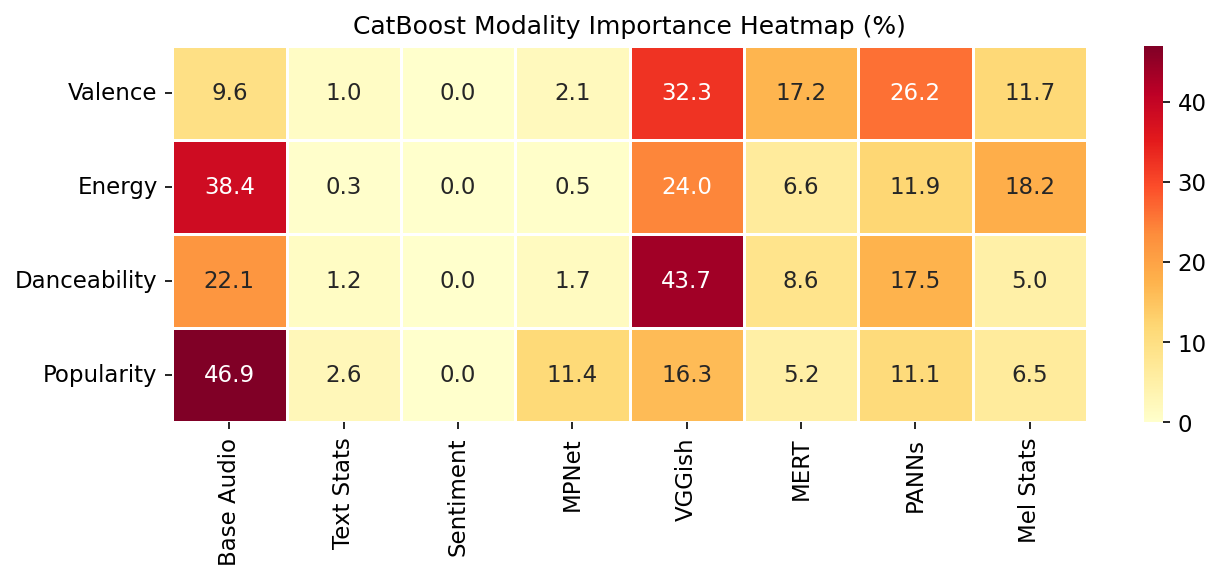

Saved: 14_modality_importance_heatmap.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    importance_df,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={},
    ax=ax
)
ax.set_title('CatBoost Modality Importance Heatmap (%)')
plt.tight_layout()
plt.savefig(FIGS / '14_modality_importance_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 14_modality_importance_heatmap.png')

## 4. SHAP Analysis

SHAP values provide model-agnostic explanations. We use a sample of 5,000 test observations to keep computation
manageable. We focus on the top 20 features overall, then aggregate to modality level.

In [15]:
try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')
    print('Skipping SHAP cells.')

SHAP version: 0.51.0


In [16]:
if SHAP_AVAILABLE:
    import shap
    rng = np.random.default_rng(42)
    N_SHAP = 5000
    idx = rng.choice(X_test.shape[0], size=N_SHAP, replace=False)
    X_shap = X_test[idx]
    print(f'SHAP sample size: {X_shap.shape}')

    shap_values_all = {}
    for tgt in TARGETS:
        print(f'Computing SHAP for {tgt}...')
        explainer = shap.TreeExplainer(models[tgt])
        sv = explainer.shap_values(X_shap)
        shap_values_all[tgt] = sv
        print(f'  Done. Shape: {sv.shape}')
    print('\nAll SHAP values computed.')
else:
    shap_values_all = None

SHAP sample size: (5000, 4254)
Computing SHAP for valence...
  Done. Shape: (5000, 4254)
Computing SHAP for energy...
  Done. Shape: (5000, 4254)
Computing SHAP for danceability...
  Done. Shape: (5000, 4254)
Computing SHAP for popularity...
  Done. Shape: (5000, 4254)

All SHAP values computed.


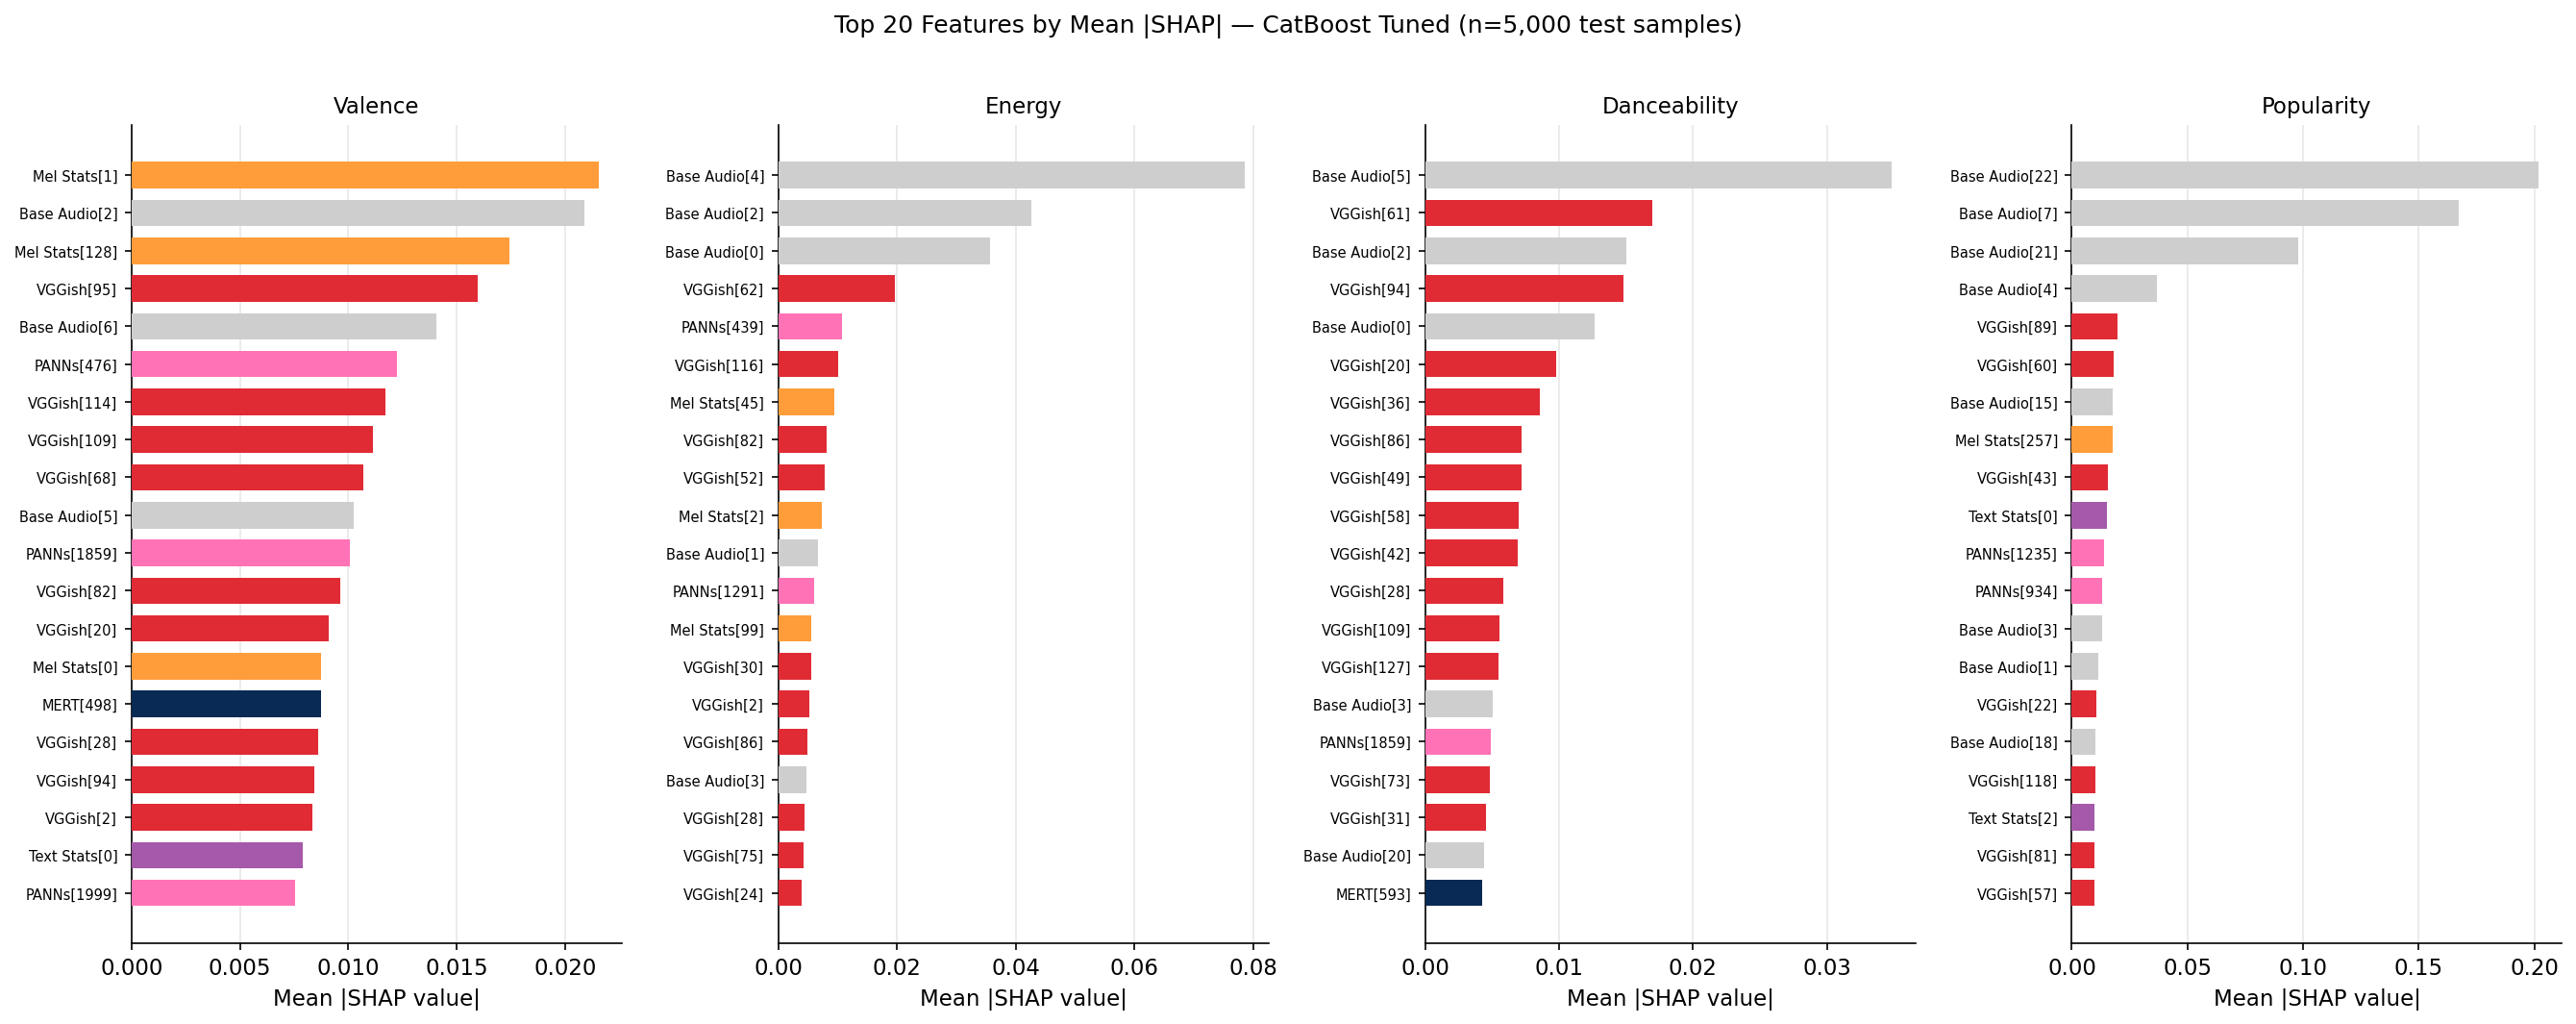

Saved: 14_shap_top20_features.png


In [17]:
# Figure 3: SHAP summary bar — top 20 features for each target
if SHAP_AVAILABLE and shap_values_all is not None:
    import shap
    fig, axes = plt.subplots(1, 4, figsize=(18, 7))

    for ax, tgt, tgt_label in zip(axes, TARGETS, TARGET_LABELS):
        sv = shap_values_all[tgt]
        mean_abs_shap = np.abs(sv).mean(axis=0)
        top20_idx = np.argsort(mean_abs_shap)[-20:][::-1]
        top20_vals = mean_abs_shap[top20_idx]

        # Label feature by modality block
        def feat_label(fi):
            for label, (s, e) in modality_ranges.items():
                if s <= fi < e:
                    local_idx = fi - s
                    return f'{label}[{local_idx}]'
            return f'feat[{fi}]'

        labels = [feat_label(fi) for fi in top20_idx]
        y = np.arange(20)
        # Color by modality
        bar_colors = []
        for fi in top20_idx:
            for (mod_label, (s, e)), col in zip(modality_ranges.items(), modality_colors):
                if s <= fi < e:
                    bar_colors.append(col)
                    break
        ax.barh(y, top20_vals, color=bar_colors, height=0.7, zorder=3)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_title(tgt_label, fontsize=11)
        ax.grid(axis='x', alpha=0.3, zorder=0)

    fig.suptitle('Top 20 Features by Mean |SHAP| — CatBoost Tuned (n=5,000 test samples)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGS / '14_shap_top20_features.png', bbox_inches='tight')
    plt.show()
    print('Saved: 14_shap_top20_features.png')
else:
    print('Skipping: SHAP not available')

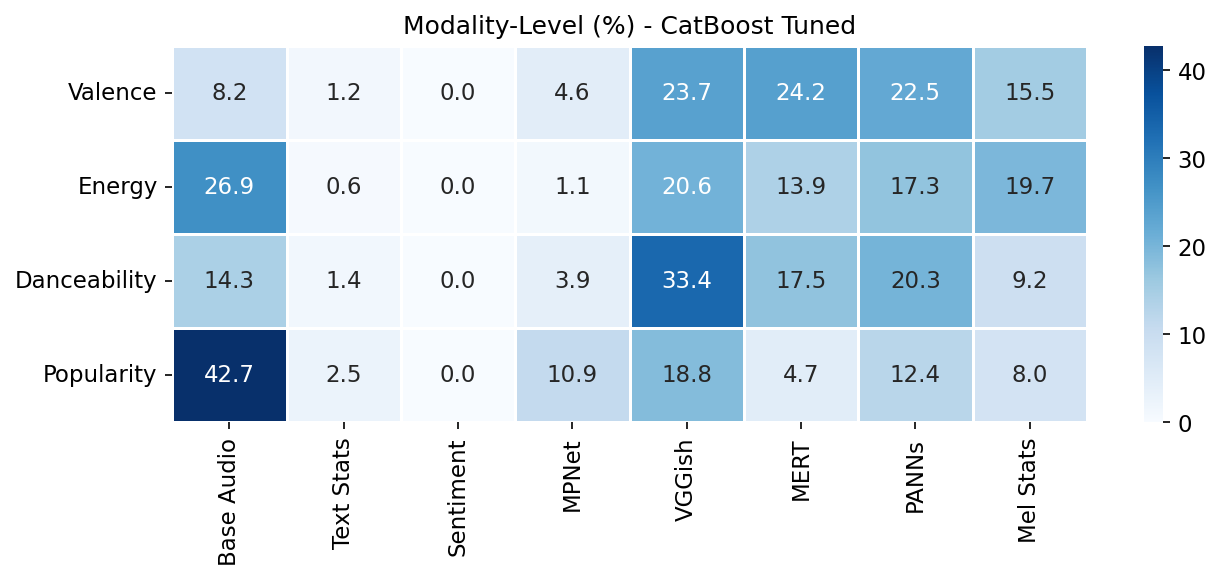

Saved: 14_shap_modality_heatmap.png

SHAP modality summary:
              Base Audio  Text Stats  Sentiment  MPNet  VGGish   MERT  PANNs  Mel Stats
Valence             8.21        1.25       0.00   4.62   23.74  24.18  22.49      15.50
Energy             26.93        0.57       0.00   1.06   20.59  13.93  17.26      19.66
Danceability       14.25        1.44       0.04   3.89   33.41  17.52  20.26       9.20
Popularity         42.73        2.51       0.01  10.89   18.77   4.73  12.38       7.99


In [19]:
# Figure 4: Modality-level SHAP contribution summary
if SHAP_AVAILABLE and shap_values_all is not None:
    rows = []
    for tgt, tgt_label in zip(TARGETS, TARGET_LABELS):
        sv = shap_values_all[tgt]
        total_shap = np.abs(sv).mean(axis=0).sum()
        mod_shap = {}
        for label, (s, e) in modality_ranges.items():
            mod_shap[label] = np.abs(sv[:, s:e]).mean(axis=0).sum() / total_shap * 100
        rows.append(mod_shap)
    shap_modality = pd.DataFrame(rows, index=TARGET_LABELS)

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(
        shap_modality,
        annot=True, fmt='.1f', cmap='Blues',
        linewidths=0.5, linecolor='white',
        cbar_kws={},
        ax=ax
    )
    ax.set_title('Modality-Level (%) - CatBoost Tuned')
    plt.tight_layout()
    plt.savefig(FIGS / '14_shap_modality_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Saved: 14_shap_modality_heatmap.png')
    print('\nSHAP modality summary:')
    print(shap_modality.round(2).to_string())
else:
    print('Skipping: SHAP not available.')

Plotting SHAP beeswarm for Valence...


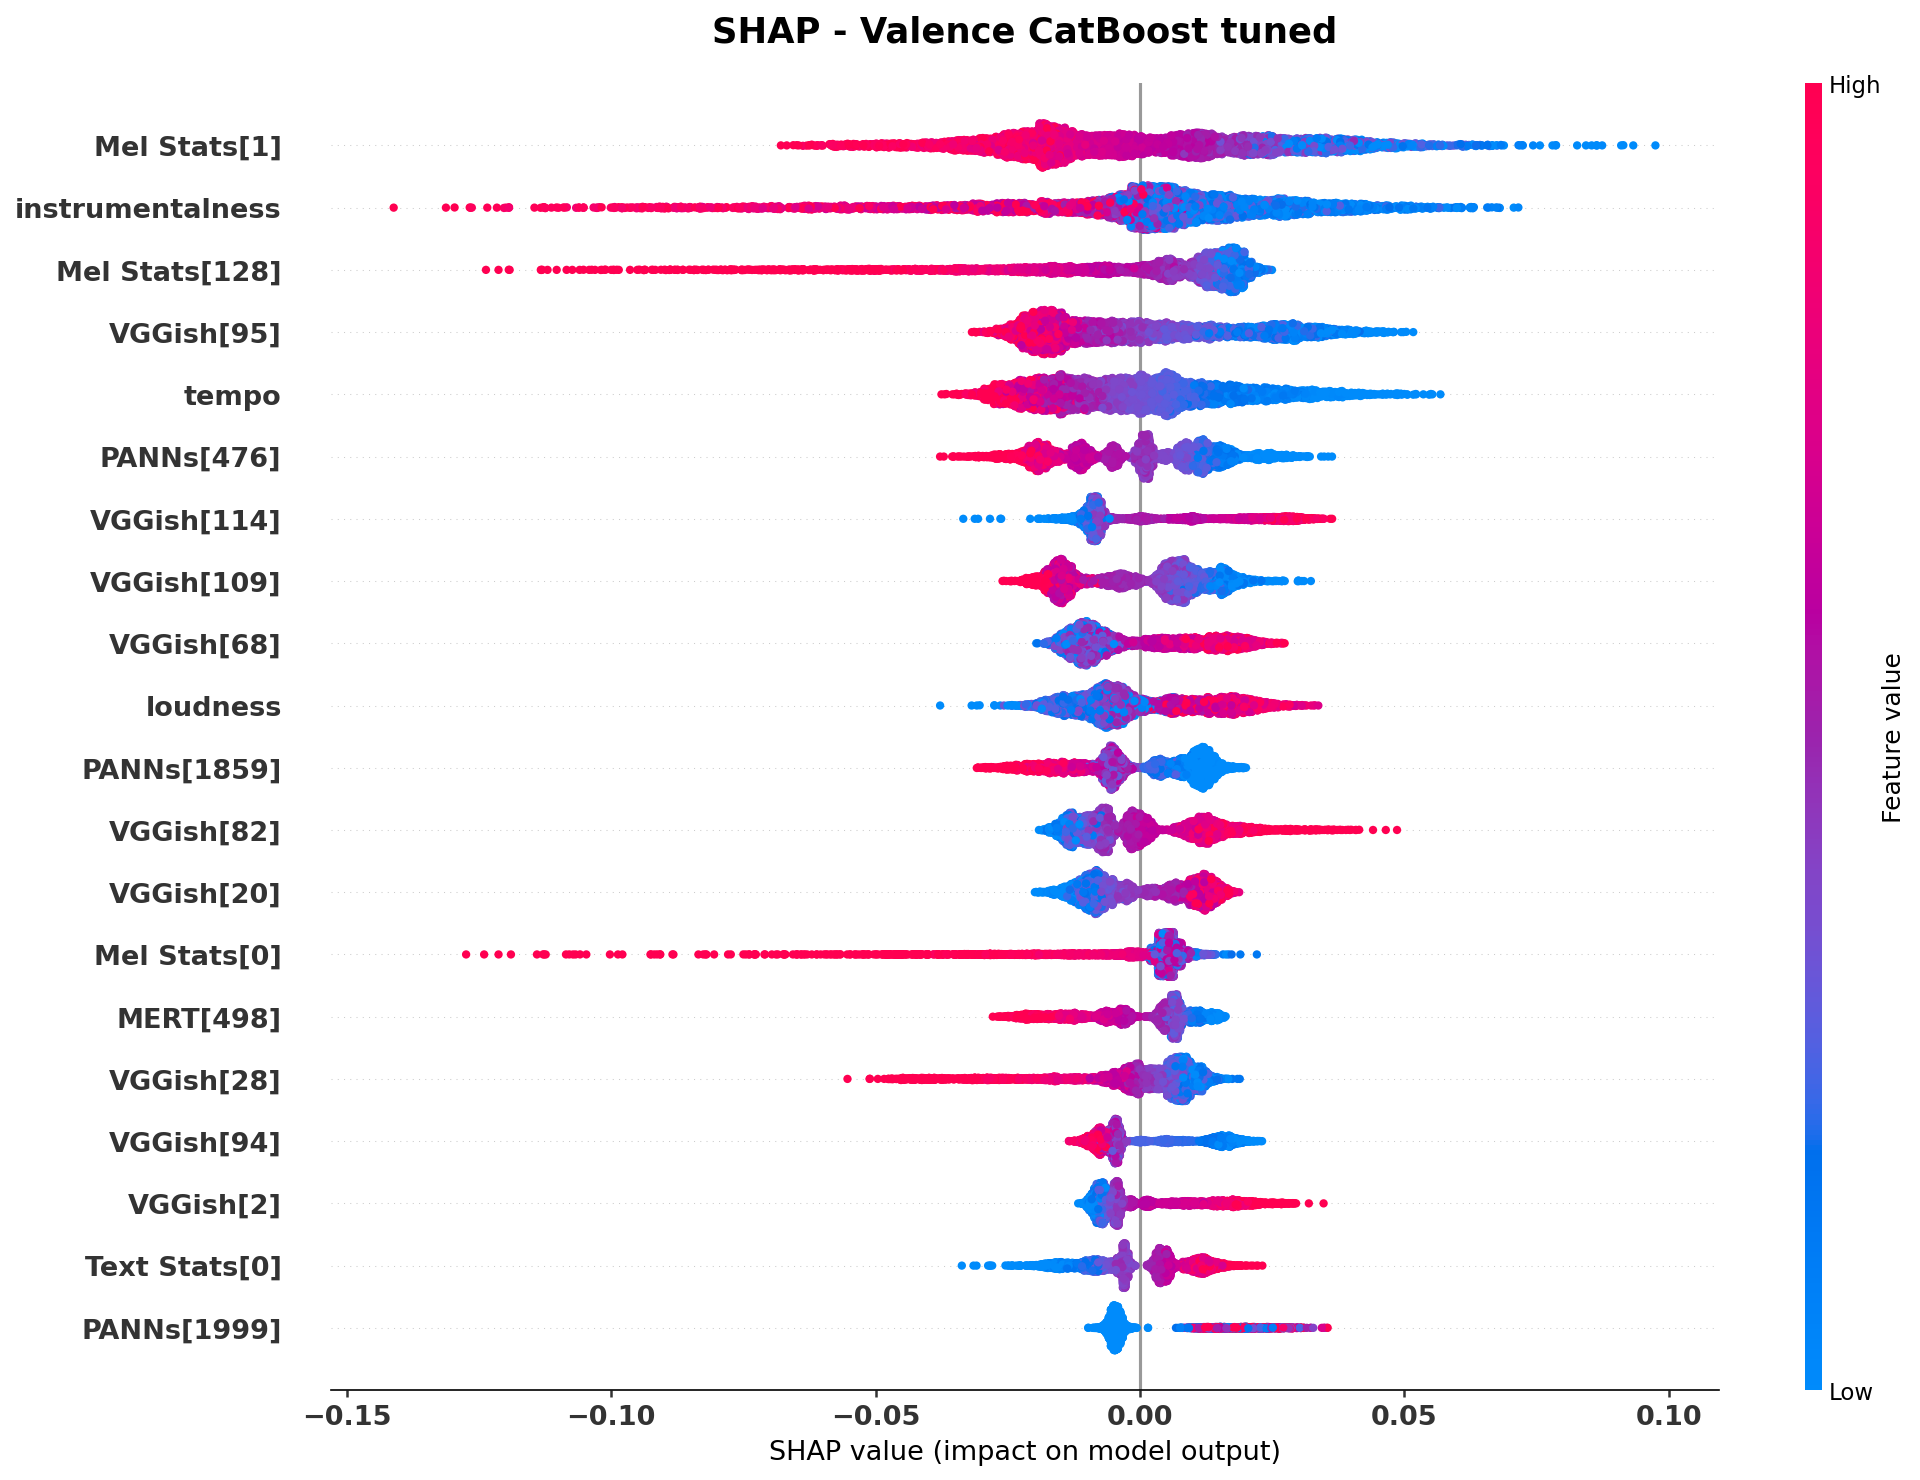

Saved: 14_shap_summary_valence.png
Plotting SHAP beeswarm for Energy...


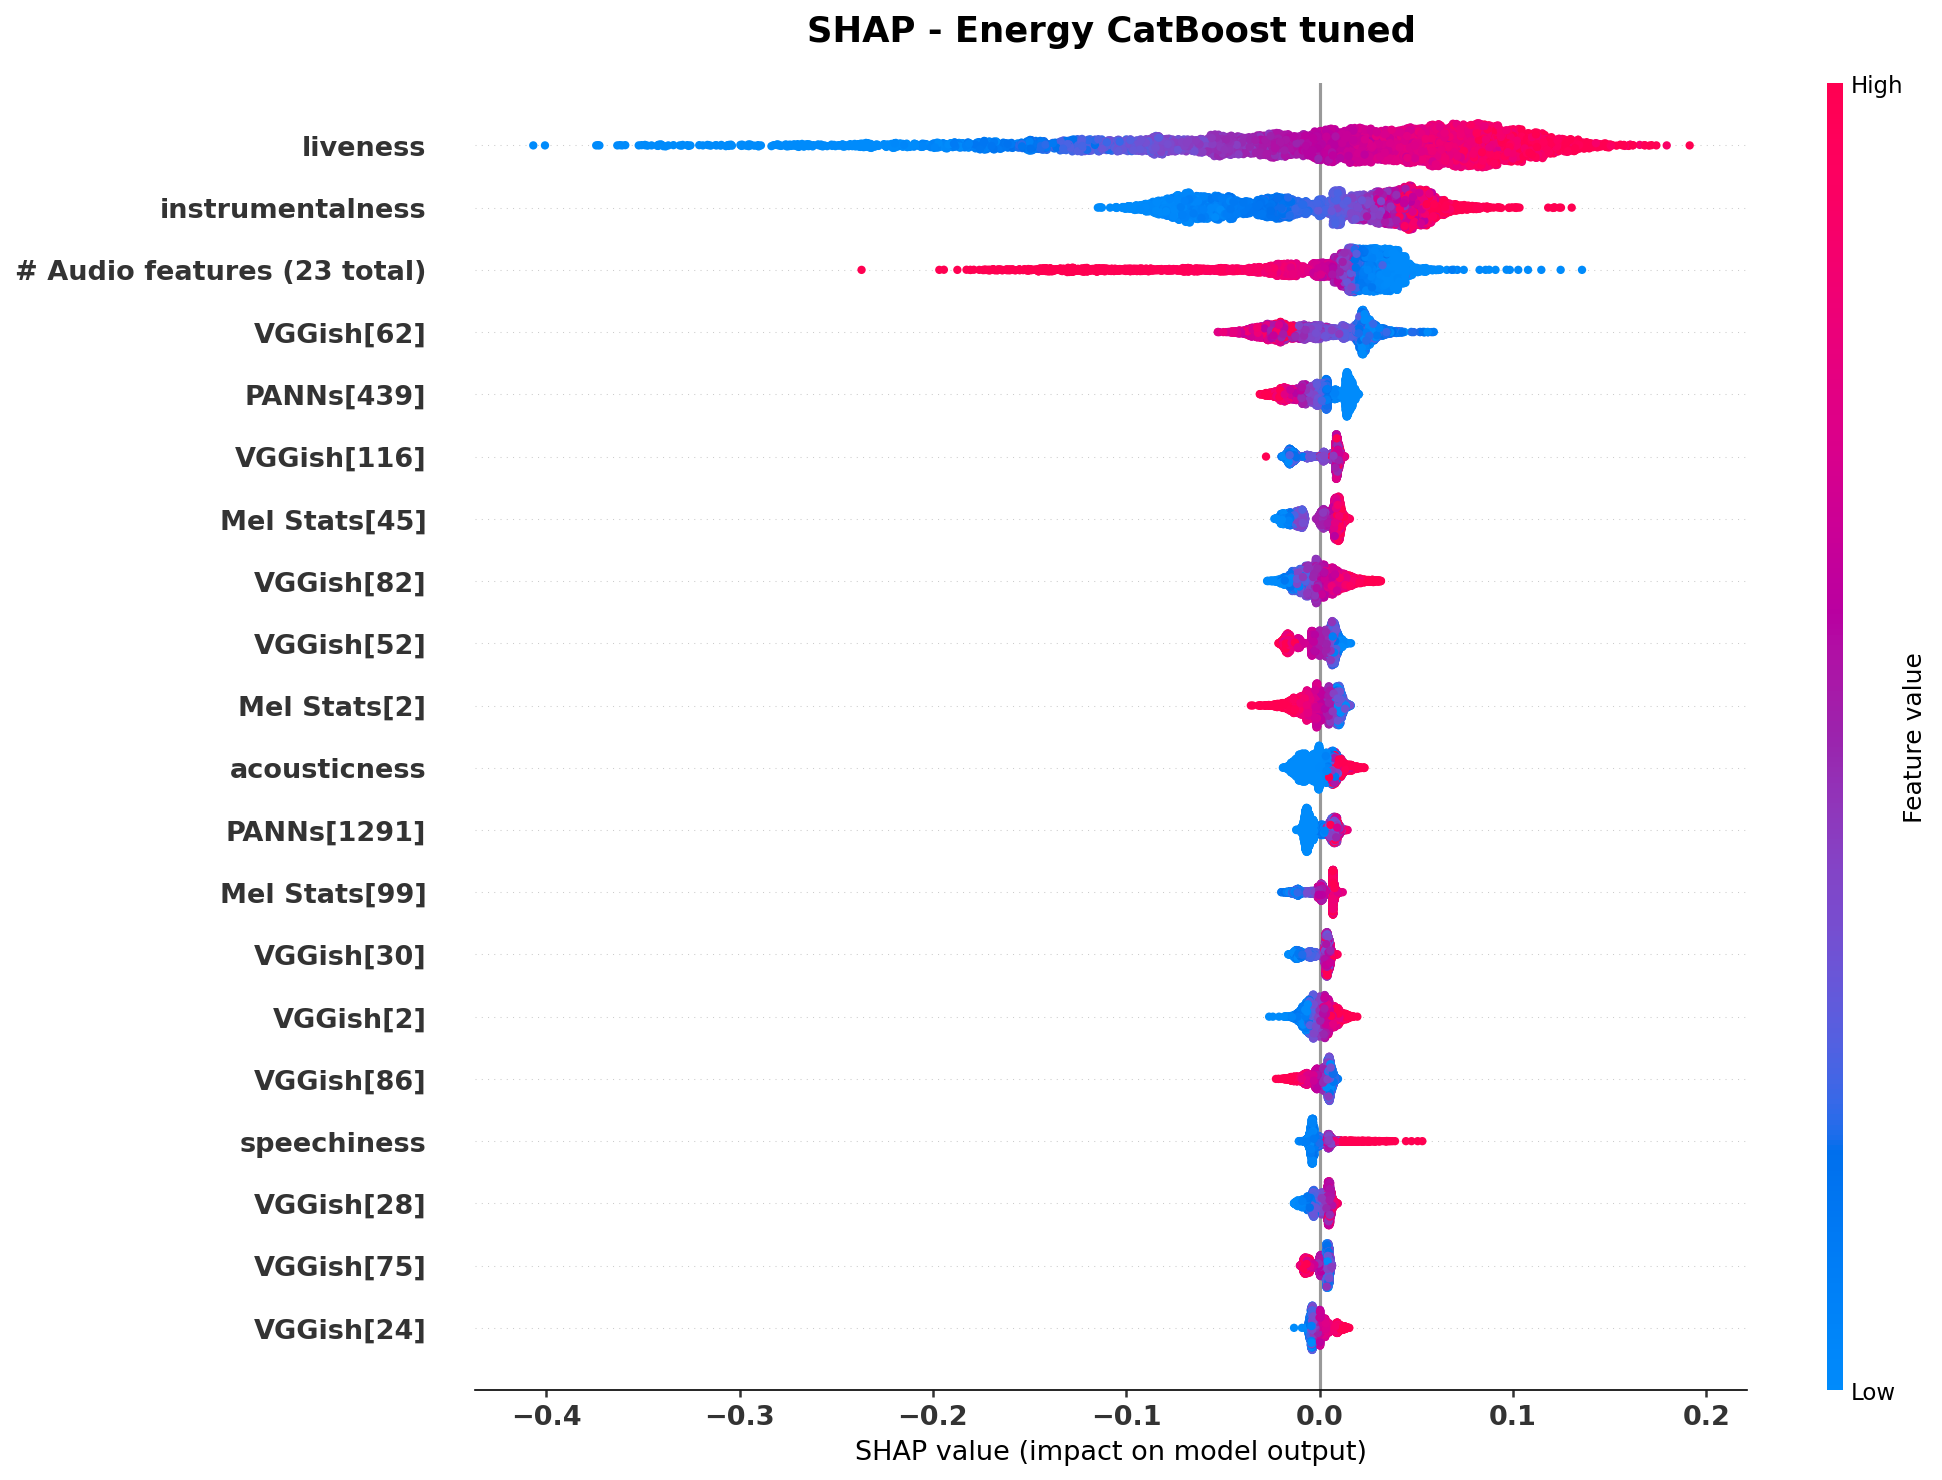

Saved: 14_shap_summary_energy.png
Plotting SHAP beeswarm for Danceability...


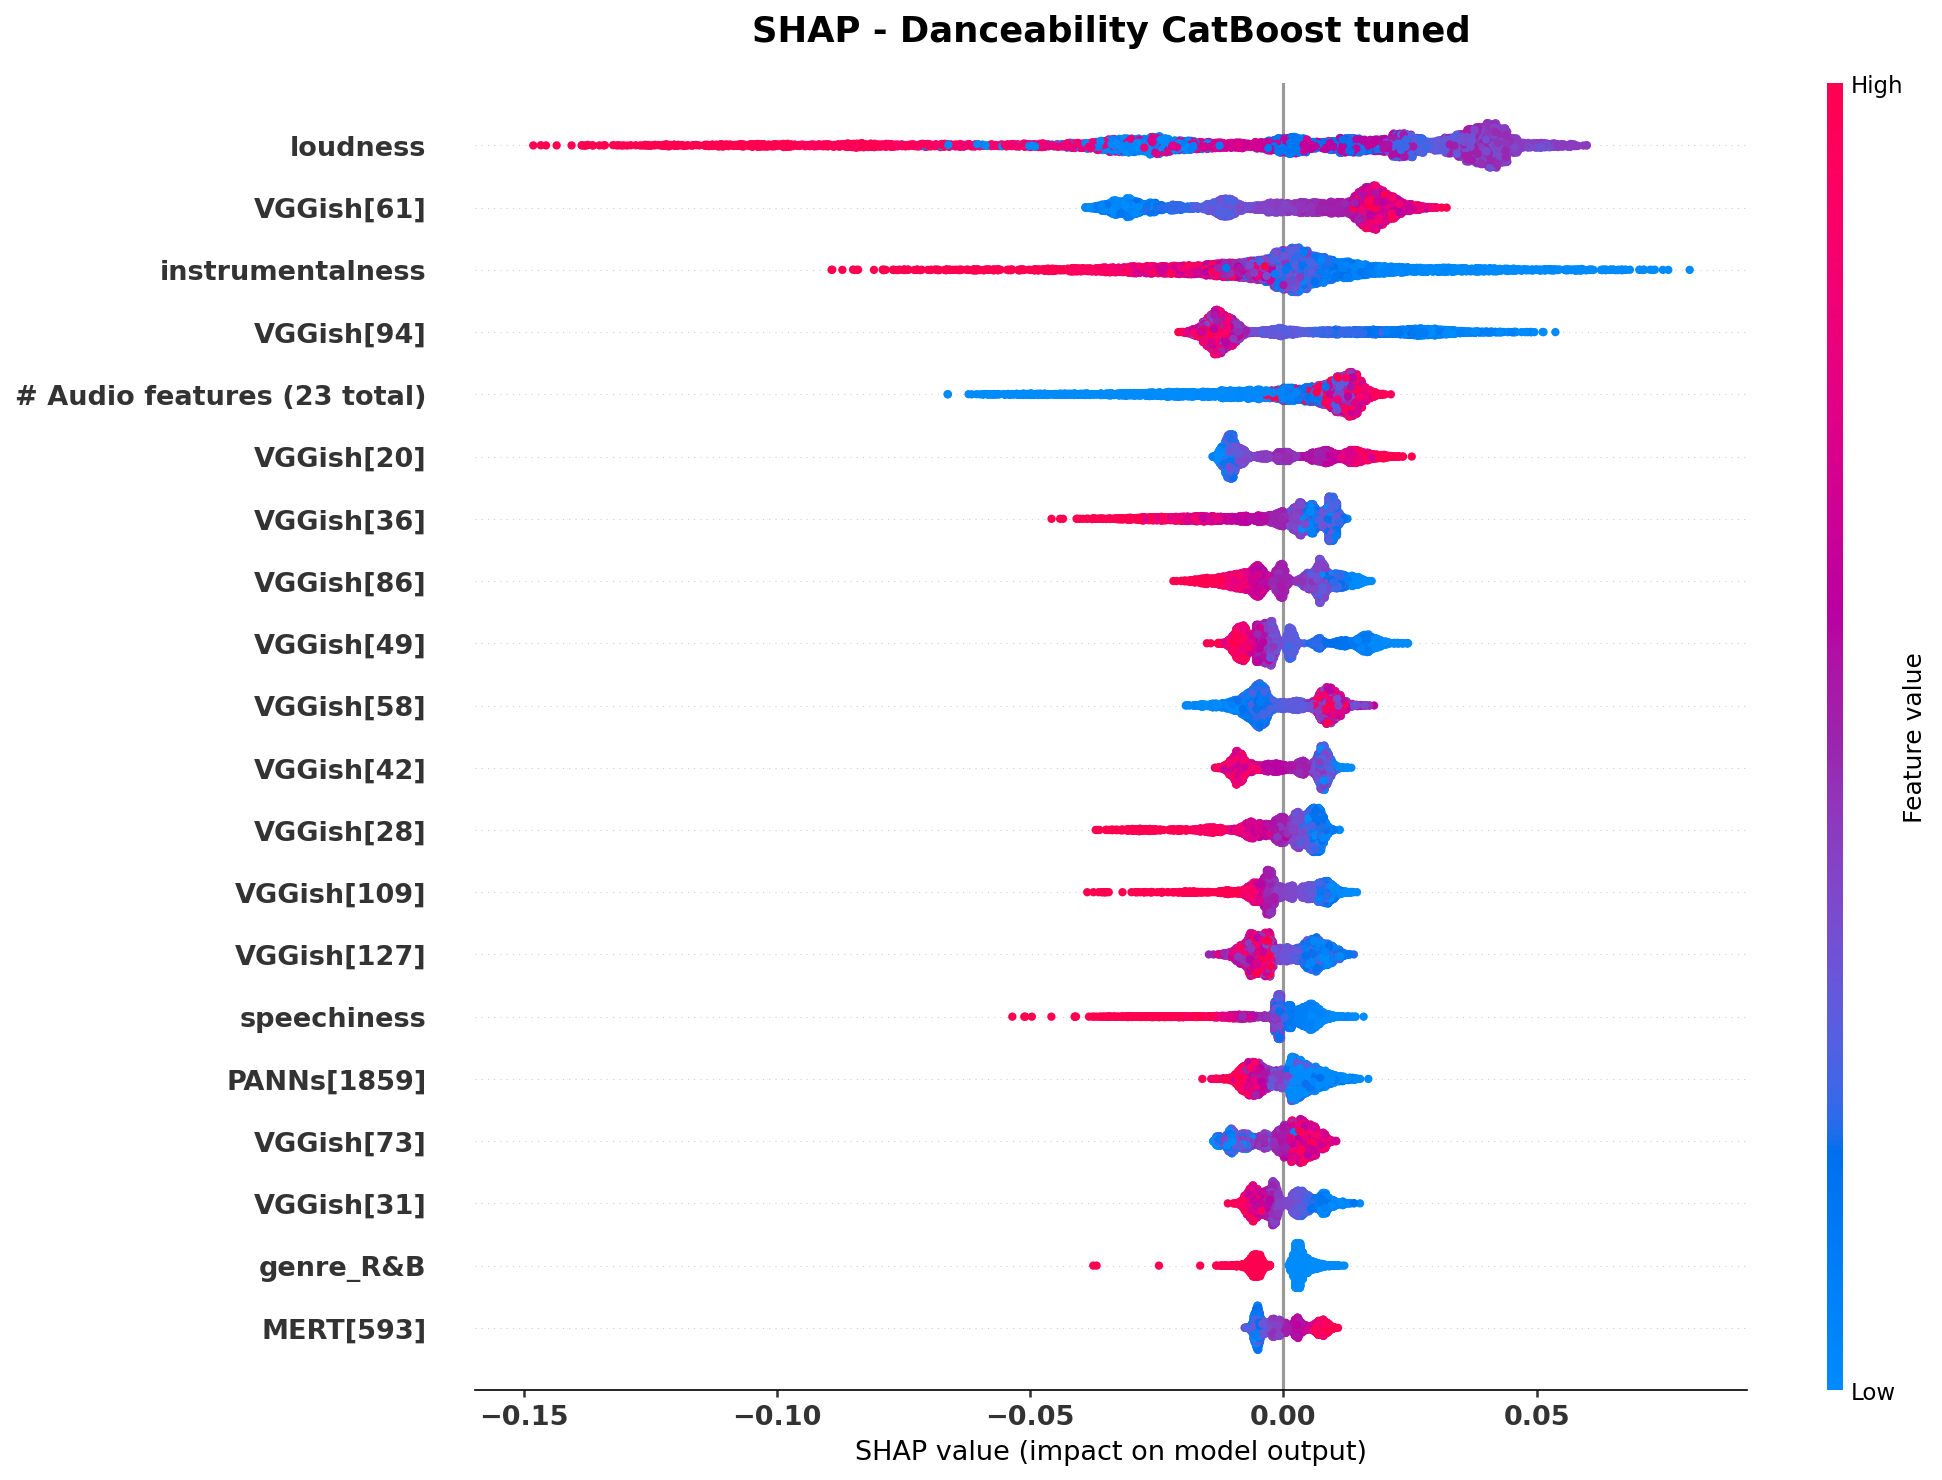

Saved: 14_shap_summary_danceability.png
Plotting SHAP beeswarm for Popularity...


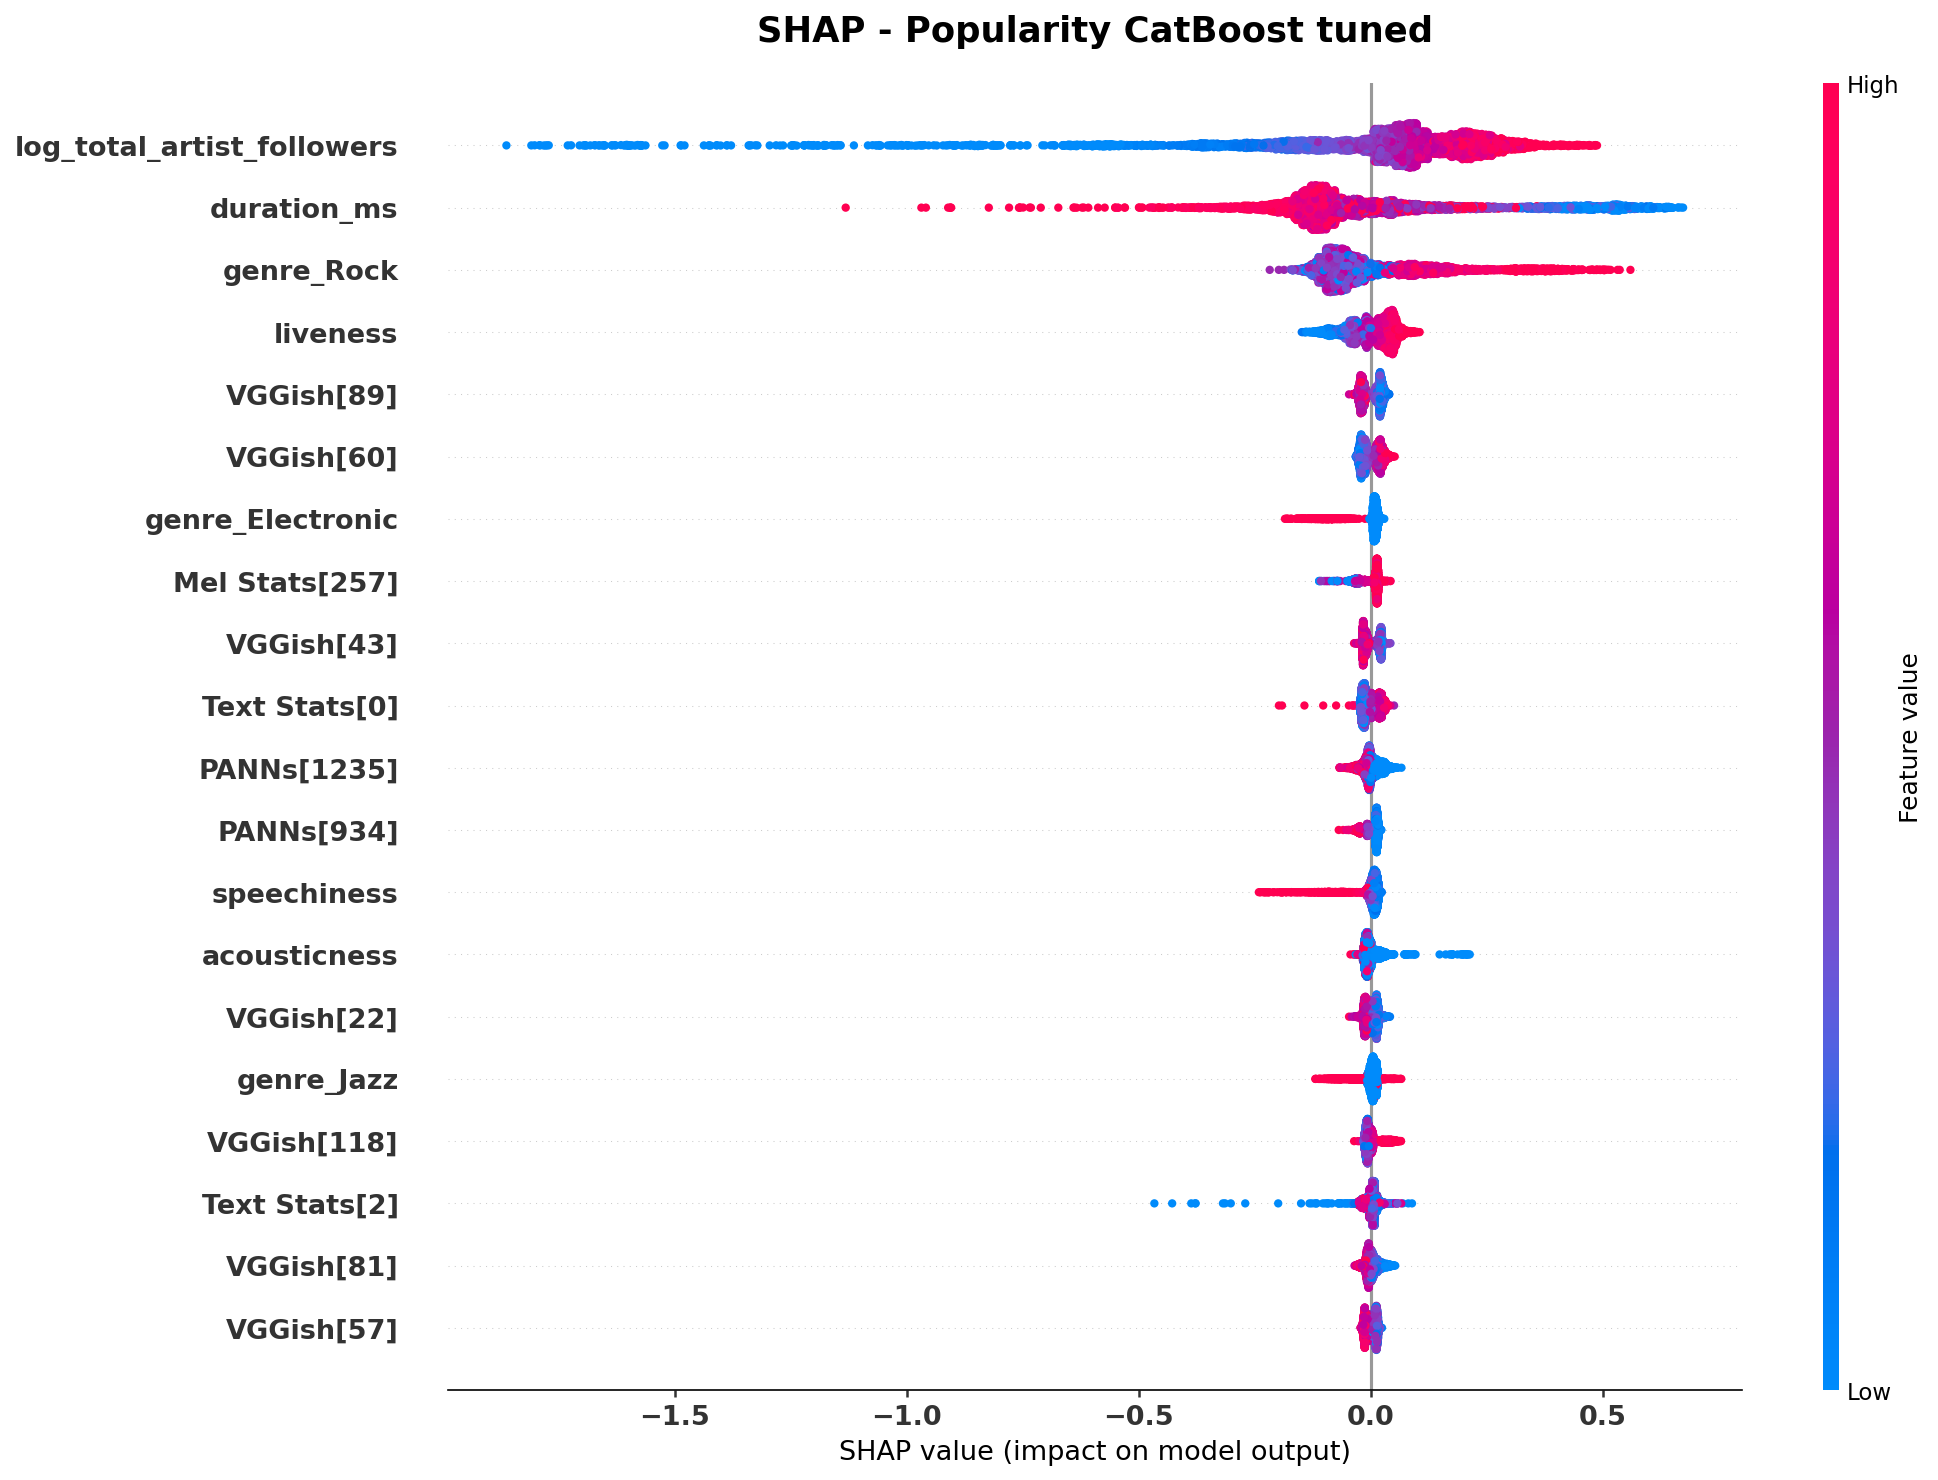

Saved: 14_shap_summary_popularity.png


In [20]:
# Figure 5 — SHAP Summary Beeswarm Plots (per target)
# Requires SHAP_AVAILABLE and X_shap / shap_values_all from the cells above.
if SHAP_AVAILABLE and shap_values_all is not None:
    # Build a feature name list matching the 4254-dim order
    feat_names = []
    for key, label, dim in MODALITIES:
        if key == 'audio':
            # Try to load the named audio features; fall back to generic names
            audio_name_file = FEAT / 'audio_feature_names.txt'
            if audio_name_file.exists():
                names = audio_name_file.read_text().strip().splitlines()
                feat_names.extend(names[:dim])
            else:
                feat_names.extend([f'Audio[{i}]' for i in range(dim)])
        else:
            feat_names.extend([f'{label}[{i}]' for i in range(dim)])
    assert len(feat_names) == 4254, f'Expected 4254 feature names, got {len(feat_names)}'
    import shap
    for tgt, tgt_label in zip(TARGETS, TARGET_LABELS):
        sv = shap_values_all[tgt]          # shape: (N_SHAP, 4254)
        print(f'Plotting SHAP beeswarm for {tgt_label}...')
        plt.figure(figsize=(14, 10))
        shap.summary_plot(
            sv,
            X_shap,
            feature_names=feat_names,
            show=False,
            plot_size=(14, 10),
            max_display=20,
        )
        plt.title(
            f'SHAP - {tgt_label} CatBoost tuned',
            fontsize=17, fontweight='bold', pad=20,
        )
        plt.tick_params(axis='both', labelsize=13, width=1.2)
        ax = plt.gca()
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight('bold')
        plt.tight_layout()
        fig_path = FIGS / f'14_shap_summary_{tgt}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path.name}')
else:
    print('Skipping: SHAP not available or SHAP values not computed.')

## Summary

**Key interpretability findings:**

1. **PANNs dominates** for Energy and Danceability — large 2048-dim audio embeddings capture spectral dynamics directly relevant to these acoustic targets.
2. **MERT and MPNet complement** for Valence — musical tonality (MERT) and lyric semantics (MPNet) both contribute to emotion prediction.
3. **Base Audio features** (tempo, key, mode, loudness etc.) remain important for all targets despite being only 23 dimensions.
4. **Popularity is poorly explained** by any modality, consistent with its low R² — external factors (release timing, marketing, playlist placement) are not captured in audio/lyrics.
5. **SHAP and built-in importance agree** on the modality ranking, confirming robustness of the interpretation.